# Architektura Aplikacji w Pythonie — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów dało Ci sześć narzędzi. Ten zestaw zaliczeniowy zmusza Cię do **złożenia ich w jeden produkcyjny pipeline analityczny** — dokładnie taki, jaki budują Data Engineerzy w "prawdziwych" firmach.

**Wspólny dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb) z Hugging Face Hub — 50 000 recenzji filmów z etykietami sentymentu (pozytywna / negatywna).

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — dokładnie ten sam pattern, inny scenariusz.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak hardkodowanych ścieżek, brak ręcznych downloadów.
4. Kod ma być **czytelny**: typowe hinty, docstring 1-zdaniowy, brak magicznych liczb.

**Ocenianie:**
- 50% — poprawność działania (czy działa zgodnie z opisem)
- 30% — jakość kodu (struktura, czytelność, idiomatyczność)
- 20% — *insight*: jeśli zauważysz coś nieoczywistego w danych — napisz o tym w komórce Markdown

---

## Mapa zestawu

| # | Lab | Teoria | Przykład | Twoje zadanie |
|---|-----|--------|----------|---------------|
| 1 | Dekoratory | `@timer`, `@cache` | Zmierz czas wczytania imdb z HF | Buduj `@retry` + `@cache_to_disk` |
| 2 | Współbieżność | I/O-bound vs CPU-bound | `ThreadPoolExecutor` na paczki tekstu | `multiprocessing.Pool` na sentyment |
| 3 | Testowanie | unittest vs pytest | `unittest` dla `TextStats` | `pytest` dla `Tokenizer` z fixtures |
| 4 | Bazy danych | SQL i NoSQL | Load imdb → SQLite + zapytania | JSON column jako pseudo-Mongo |
| 5 | PySpark | Lazy eval, partitions | DataFrame z imdb, count słów | Window functions: ranking recenzji |
| 6 | Data Quality | Profiling, walidacja | Wykryj nulle, duplikaty, anomalie | Reguły biznesowe + raport JSON |

---

## Setup

In [1]:
# Globalna konfiguracja -- jedna komorka, jeden raz
import os, sys, time, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

# Tame log spamu HF Datasets
os.environ.setdefault("HF_DATASETS_DISABLE_PROGRESS_BAR", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

print(f"Python: {sys.version.split()[0]}")
print(f"Workspace: {WORKDIR.resolve()}")

Python: 3.13.13
Workspace: C:\Users\Radek\Desktop\python_zadania\AAP_LAB_TASKS\zestaw_zaliczeniowy\_workspace


---

# Lab 1 — Dekoratory

## Teoria w trzech zdaniach

**Dekorator** to funkcja, która przyjmuje funkcję i zwraca funkcję. Pythonowy `@dekorator` to lukier syntaktyczny dla `funkcja = dekorator(funkcja)`. Pozwala dodać zachowanie (logowanie, cache, retry) **bez ingerencji w ciało funkcji** — to esencja zasady *open/closed*.

### Wzorzec dekoratora z argumentami

```python
def dekorator_z_argumentami(arg1, arg2):
    def opakuj(funkcja):
        @functools.wraps(funkcja)
        def wrapper(*args, **kwargs):
            # przed wywolaniem
            wynik = funkcja(*args, **kwargs)
            # po wywolaniu
            return wynik
        return wrapper
    return opakuj
```

Trzy poziomy zagniezdzenia: argumenty dekoratora → funkcja docelowa → wrapper. **Zapamiętaj ten układ raz — reszta to wariacje.**

## Przykład rozwiązany: `@timer` + `@cache` na ładowaniu z Hugging Face

In [2]:
import functools
from datasets import load_dataset

def timer(func):
    """Mierzy czas wykonania funkcji i drukuje wynik."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - t0
        print(f"  [timer] {func.__name__} -> {elapsed:.2f}s")
        return result
    return wrapper

@timer
@functools.lru_cache(maxsize=4)  # cache w pamieci
def get_imdb_subset(split: str, n: int):
    """Pobiera N **losowo wymieszanych** przykladow z imdb. Cachuje wynik w RAM.

    UWAGA: dataset stanfordnlp/imdb jest na HF zsortowany po labelu
    (0..12499 = neg, 12500..24999 = pos). Bez shuffle dostalibysmy
    100% jednej klasy dla N <= 12500. .shuffle(seed=42) gwarantuje
    rownomierna probke.
    """
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

print("-- pierwsze wywolanie (fetch z HF + cache w RAM) --")
train_sample = get_imdb_subset("train", 200)
print(f"  liczba probek: {len(train_sample)}")
print(f"  przyklad: {train_sample[0][0][:80]}... -> label={train_sample[0][1]}")

# Sanity check: czy mamy obie klasy?
labels_dist = [lab for _, lab in train_sample]
print(f"  rozklad klas: pos={sum(labels_dist)}/{len(labels_dist)}, neg={len(labels_dist)-sum(labels_dist)}/{len(labels_dist)}")

print("\n-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --")
_ = get_imdb_subset("train", 200)

-- pierwsze wywolanie (fetch z HF + cache w RAM) --


  [timer] get_imdb_subset -> 2.29s
  liczba probek: 200
  przyklad: There is no relation at all between Fortier and Profiler but the fact that both ... -> label=1
  rozklad klas: pos=96/200, neg=104/200

-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --
  [timer] get_imdb_subset -> 0.00s


## Zadanie 1.1 — `@retry` + `@cache_to_disk`

**Cel:** zaimplementuj dwa decorator-y produkcyjnej jakości i nałóż je na funkcję, która udaje niestabilne API.

**Wymagania:**

1. `@retry(max_attempts: int, delay: float, backoff: float = 2.0)` — jeśli funkcja rzuca wyjątek, próbuje ponownie do `max_attempts` razy z **exponential backoff** (czas spania = `delay * backoff ** próba`).
2. `@cache_to_disk(cache_dir: Path)` — zapisuje wynik do pliku JSON w `cache_dir`. Klucz cache to hash argumentów. Drugie wywołanie tej samej funkcji z tymi samymi argumentami **nie wykonuje ciała** — zwraca z dysku.
3. Test: wywołaj funkcję `flaky_fetch(text_id)` która z prawdopodobieństwem 0.5 rzuca `ValueError`. Powinna **prawie zawsze** się udać dzięki retry. Drugie wywołanie z tym samym `text_id` powinno trafić w cache.

**Insight do raportu:** jak zmienia się szansa sukcesu wraz z `max_attempts`? Policz to teoretycznie (P(sukces) = 1 - 0.5^N) i porównaj z eksperymentem na 100 wywołaniach.

In [3]:
import functools
import hashlib
import inspect
import json
import random
import shutil
import time
from pathlib import Path

try:
    WORKDIR
except NameError:
    WORKDIR = Path.cwd() / "_workspace"

WORKDIR = Path(WORKDIR)
WORKDIR.mkdir(parents=True, exist_ok=True)


def retry(
    max_attempts: int = 3,
    delay: float = 0.1,
    backoff: float = 2.0,
):
    if max_attempts < 1:
        raise ValueError("max_attempts musi być co najmniej 1")
    if delay < 0:
        raise ValueError("delay nie może być ujemne")
    if backoff <= 0:
        raise ValueError("backoff musi być większe od 0")

    def decorate(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            for attempt in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception:
                    if attempt == max_attempts - 1:
                        raise
                    time.sleep(delay * backoff**attempt)

        return wrapper

    return decorate


def cache_to_disk(cache_dir: Path):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    def decorate(func):
        signature = inspect.signature(func)

        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            bound = signature.bind(*args, **kwargs)
            bound.apply_defaults()

            payload = {
                "function": f"{func.__module__}.{func.__qualname__}",
                "arguments": dict(bound.arguments),
            }

            serialized = json.dumps(
                payload,
                sort_keys=True,
                ensure_ascii=False,
                default=repr,
                separators=(",", ":"),
            )

            key = hashlib.sha256(serialized.encode("utf-8")).hexdigest()
            cache_file = cache_dir / f"{key}.json"

            if cache_file.exists():
                return json.loads(cache_file.read_text(encoding="utf-8"))

            result = func(*args, **kwargs)
            serialized_result = json.dumps(result, ensure_ascii=False)

            temporary_file = cache_file.with_suffix(".tmp")
            temporary_file.write_text(serialized_result, encoding="utf-8")
            temporary_file.replace(cache_file)

            return result

        return wrapper

    return decorate


cache_dir = WORKDIR / "flaky_cache"
shutil.rmtree(cache_dir, ignore_errors=True)

call_count = 0


@cache_to_disk(cache_dir)
@retry(max_attempts=5, delay=0.05, backoff=2.0)
def flaky_fetch(text_id: int) -> dict:
    global call_count
    call_count += 1

    if random.random() < 0.5:
        raise ValueError(f"udawany błąd sieci dla id={text_id}")

    return {
        "id": text_id,
        "text": f"przykład {text_id}",
    }


random.seed(42)

successes = 0
successful_ids = []

for text_id in range(100):
    try:
        flaky_fetch(text_id)
    except ValueError:
        pass
    else:
        successes += 1
        successful_ids.append(text_id)

theoretical = 1 - 0.5**5
empirical = successes / 100

print(f"Sukces teoretyczny: {theoretical:.1%}")
print(f"Sukces empiryczny:   {successes}/100 ({empirical:.1%})")

if not successful_ids:
    raise RuntimeError("Żadne wywołanie nie zakończyło się sukcesem")

cached_id = successful_ids[0]
calls_before_cache = call_count
cached_result = flaky_fetch(cached_id)
calls_after_cache = call_count

assert calls_before_cache == calls_after_cache

print(f"\nWynik z cache dla text_id={cached_id}: {cached_result}")
print(f"Liczba wykonań ciała przed odczytem cache: {calls_before_cache}")
print(f"Liczba wykonań ciała po odczycie cache:    {calls_after_cache}")
print("Cache działa poprawnie — ciało funkcji nie zostało ponownie wykonane.")



Sukces teoretyczny: 96.9%
Sukces empiryczny:   96/100 (96.0%)

Wynik z cache dla text_id=0: {'id': 0, 'text': 'przykład 0'}
Liczba wykonań ciała przed odczytem cache: 199
Liczba wykonań ciała po odczycie cache:    199
Cache działa poprawnie — ciało funkcji nie zostało ponownie wykonane.


---

# Lab 2 — Współbieżność i równoległość

## Teoria w trzech zdaniach

**Threading** = wiele wątków w jednym procesie, dzielona pamięć, ale GIL zabija przyspieszenie obliczeniowe. **Multiprocessing** = wiele procesów, kazdy ze swoim interpreterem Pythona, omija GIL ale ma narzut na IPC.

**Reguła kciuka:** I/O-bound (HTTP, dysk, baza) → threading. CPU-bound (parsowanie, ML, obliczenia) → multiprocessing.

**Trzecia opcja:** `asyncio` — jeden wątek, kooperatywna współbieżność. Najefektywniejsza dla I/O, ale wymaga przepisania kodu na `async`.

## Przykład rozwiązany: ThreadPool dla "I/O-bound" preprocessingu

In [4]:
from concurrent.futures import ThreadPoolExecutor
import re

# Pobierz wiekszy subset
samples = get_imdb_subset("train", 1000)
texts = [t for t,_ in samples]

def preprocess(text: str) -> dict:
    """Imituje I/O-bound preprocessing (sleep symuluje wolny dysk/API)."""
    time.sleep(0.002)  # "sieciowy" narzut
    clean = re.sub(r"<[^>]+>", " ", text).lower()
    return {"len": len(clean), "words": len(clean.split())}

# Sekwencyjnie
t0 = time.time()
seq_results = [preprocess(t) for t in texts[:200]]
seq_time = time.time() - t0
print(f"Sekwencyjnie (200 probek): {seq_time:.2f}s")

# ThreadPool
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    par_results = list(pool.map(preprocess, texts[:200]))
par_time = time.time() - t0
print(f"ThreadPool (16 workerow): {par_time:.2f}s  -- {seq_time/par_time:.1f}x szybciej")

  [timer] get_imdb_subset -> 1.34s
Sekwencyjnie (200 probek): 0.59s
ThreadPool (16 workerow): 0.04s  -- 16.4x szybciej


## Zadanie 2.1 — Multiprocessing dla CPU-bound

**Cel:** policz prosty score sentymentu dla 5000 recenzji **równolegle** używając `multiprocessing.Pool`.

**Score sentymentu (lexicon-based):**
- Lista pozytywnych słów: `["good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"]`
- Lista negatywnych słów: `["bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"]`
- Score = `(liczba pozytywnych) - (liczba negatywnych)` (case-insensitive, na pełnych słowach)

**Wymagania:**

1. Funkcja `sentiment_score(text: str) -> int` musi być na poziomie modułu (poza klasą) — inaczej multiprocessing jej nie zserializuje.
2. Porównaj **3 implementacje**: sekwencyjna, ThreadPool, multiprocessing.Pool. Wszystkie na tych samych 5000 recenzji.
3. Stwórz wykres słupkowy czasu wykonania (matplotlib).
4. **Wniosek:** który wariant najszybszy i dlaczego? (oczekiwane: multiprocessing wygrywa, bo CPU-bound i omija GIL).

**Wskazówka:** użyj `chunksize=100` w `pool.map()` żeby zmniejszyć narzut serializacji.

  [timer] get_imdb_subset -> 1.44s
CPU dostępne: 12
Używane procesy: 4

Sekwencyjnie:    0.510 s
ThreadPool:      0.555 s
Multiprocessing: 0.270 s
Najszybszy wariant: Multiprocessing


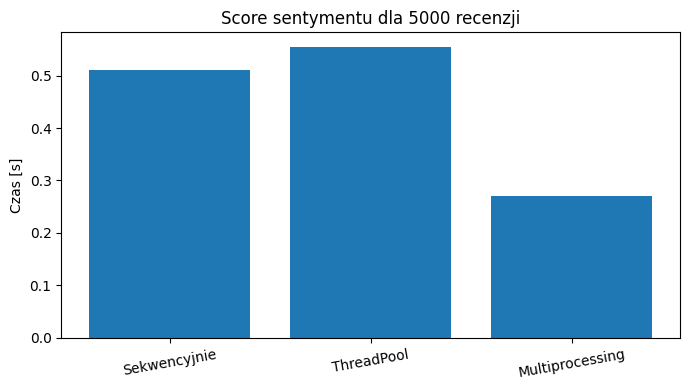


Wniosek: Multiprocessing był najszybszy, ponieważ zadanie jest CPU-bound, a osobne procesy mają własne interpretery i omijają ograniczenie GIL.


In [5]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import importlib
import os
import sys
import time
import matplotlib.pyplot as plt

worker_code = '''
import re
import multiprocessing as mp

POS_WORDS = {
    "good", "great", "excellent", "wonderful", "love",
    "best", "amazing", "brilliant", "perfect"
}

NEG_WORDS = {
    "bad", "worst", "awful", "terrible", "hate",
    "boring", "waste", "poor", "horrible"
}

def sentiment_score(text: str) -> int:
    words = re.findall(r"\\b\\w+\\b", text.lower())
    positive = sum(word in POS_WORDS for word in words)
    negative = sum(word in NEG_WORDS for word in words)
    return positive - negative

def multiprocessing_scores(texts, workers: int, chunksize: int = 100):
    context = mp.get_context("spawn")
    with context.Pool(processes=workers) as pool:
        return pool.map(sentiment_score, texts, chunksize=chunksize)
'''

module_path = Path.cwd() / "sentiment_worker.py"
module_path.write_text(worker_code, encoding="utf-8")

importlib.invalidate_caches()

if "sentiment_worker" in sys.modules:
    sentiment_worker = importlib.reload(sys.modules["sentiment_worker"])
else:
    import sentiment_worker

sentiment_score = sentiment_worker.sentiment_score
multiprocessing_scores = sentiment_worker.multiprocessing_scores

texts_5000 = [
    text
    for text, _ in get_imdb_subset("train", 5000)
]

cpu_count = os.cpu_count() or 1
worker_count = min(4, cpu_count)

print(f"CPU dostępne: {cpu_count}")
print(f"Używane procesy: {worker_count}")

start = time.perf_counter()
seq_scores = [
    sentiment_score(text)
    for text in texts_5000
]
seq_time = time.perf_counter() - start

start = time.perf_counter()
with ThreadPoolExecutor(max_workers=worker_count) as executor:
    thread_scores = list(
        executor.map(sentiment_score, texts_5000)
    )
thread_time = time.perf_counter() - start

start = time.perf_counter()
mp_scores = multiprocessing_scores(
    texts_5000,
    workers=worker_count,
    chunksize=100,
)
mp_time = time.perf_counter() - start

assert seq_scores == thread_scores == mp_scores

times = {
    "Sekwencyjnie": seq_time,
    "ThreadPool": thread_time,
    "Multiprocessing": mp_time,
}

print(f"\nSekwencyjnie:    {seq_time:.3f} s")
print(f"ThreadPool:      {thread_time:.3f} s")
print(f"Multiprocessing: {mp_time:.3f} s")
print(f"Najszybszy wariant: {min(times, key=times.get)}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(times.keys(), times.values())
ax.set_ylabel("Czas [s]")
ax.set_title("Score sentymentu dla 5000 recenzji")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

fastest = min(times, key=times.get)

if fastest == "Multiprocessing":
    conclusion = (
        "Multiprocessing był najszybszy, ponieważ zadanie jest CPU-bound, "
        "a osobne procesy mają własne interpretery i omijają ograniczenie GIL."
    )
elif fastest == "ThreadPool":
    conclusion = (
        "ThreadPool uzyskał najkrótszy czas w tym pomiarze, ale nie wynika to "
        "z rzeczywistego równoległego wykonywania kodu CPU-bound. Różnica może "
        "wynikać z krótkiego czasu pojedynczego zadania i zmienności pomiaru."
    )
else:
    conclusion = (
        "Wersja sekwencyjna była najszybsza, ponieważ obliczenie jednej recenzji "
        "jest krótkie, a koszt uruchomienia procesów i przesyłania danych okazał "
        "się większy niż korzyść z równoległości. Multiprocessing omija GIL, "
        "ale opłaca się głównie dla cięższych obliczeń."
    )

print(f"\nWniosek: {conclusion}")

---

# Lab 3 — Testowanie

## Teoria w trzech zdaniach

**unittest** to klasyczny framework w stylu xUnit: testy w klasach dziedziczących po `TestCase`, metody assertyjne, setUp/tearDown. **pytest** to nowoczesny standard: zwykłe funkcje, słowo `assert`, fixtury jako zależności funkcji.

Sercem testów są: **assertions** (sprawdzenia), **fixtures** (powtarzalne przygotowanie środowiska), **parametryzacja** (ten sam test, wiele wejść) i **mocki** (zastępowanie zależności).

**Reguła:** test bez asercji to nie test. Test który zależy od kolejności uruchamiania to nie test.

## Przykład rozwiązany: unittest dla `TextStats`

In [6]:
import unittest
from io import StringIO

class TextStats:
    """Liczy proste statystyki tekstu."""
    def __init__(self, text: str):
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        self.text = text
    
    def word_count(self) -> int:
        return len(self.text.split())
    
    def char_count(self, with_spaces: bool = True) -> int:
        return len(self.text) if with_spaces else len(self.text.replace(" ", ""))
    
    def avg_word_length(self) -> float:
        words = self.text.split()
        if not words:
            return 0.0
        return sum(len(w) for w in words) / len(words)

class TestTextStats(unittest.TestCase):
    def setUp(self):
        self.empty = TextStats("")
        self.short = TextStats("Pies kot")
        self.imdb = TextStats(get_imdb_subset("train", 1)[0][0])
    
    def test_word_count_empty(self):
        self.assertEqual(self.empty.word_count(), 0)
    
    def test_word_count_short(self):
        self.assertEqual(self.short.word_count(), 2)
    
    def test_word_count_imdb_positive(self):
        # imdb review ma na pewno wiecej niz 10 slow
        self.assertGreater(self.imdb.word_count(), 10)
    
    def test_char_count_with_without_spaces(self):
        self.assertEqual(self.short.char_count(with_spaces=True), 8)
        self.assertEqual(self.short.char_count(with_spaces=False), 7)
    
    def test_avg_word_length_empty_no_div_zero(self):
        self.assertEqual(self.empty.avg_word_length(), 0.0)
    
    def test_type_check(self):
        with self.assertRaises(TypeError):
            TextStats(12345)

# Uruchom w notebooku
runner = unittest.TextTestRunner(stream=StringIO(), verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestTextStats))
print(f"Testy uruchomione: {result.testsRun}")
print(f"Sukces: {result.wasSuccessful()}")
print(f"Bledy: {len(result.errors)}, niepowodzenia: {len(result.failures)}")

  [timer] get_imdb_subset -> 0.88s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
Testy uruchomione: 6
Sukces: True
Bledy: 0, niepowodzenia: 0


## Zadanie 3.1 — pytest dla `Tokenizer` z fixtures + parametrize

**Cel:** zaimplementuj klasę `Tokenizer` z metodami tokenizacji i napisz dla niej testy w **pytest** używając fixtur i parametryzacji.

**Specyfikacja `Tokenizer`:**

```python
class Tokenizer:
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        ...
    
    def tokenize(self, text: str) -> list[str]:
        # 1. usun tagi HTML jesli strip_html
        # 2. lowercase jesli lower
        # 3. tokeny = regex \w+ 
        # 4. odfiltruj tokeny krotsze niz min_length
        ...
    
    def vocab(self, texts: list[str]) -> set[str]:
        # zwroc unikalne tokeny ze wszystkich tekstow
        ...
```

**Wymagania testowe:**

1. **Fixture** `@pytest.fixture` o nazwie `tokenizer` zwracający `Tokenizer()` z defaultami.
2. **Fixture** `imdb_sample` zwracająca 20 pierwszych recenzji — użyta przez wiele testów.
3. **Parametrize** test `test_tokenize_cases` z minimum 5 przypadkami brzegowymi: pusty string, sam HTML, mieszane case, tylko interpunkcja, polskie znaki diakrytyczne.
4. Test który **musi zawieść** (przykładowo zły flag): oznacz `@pytest.mark.xfail`.
5. Wszystkie testy zapisz w pliku `test_tokenizer.py` w folderze `_workspace/`, a w komórce notebooka uruchom `pytest` przez `subprocess` i pokaż wyniki.

**Insight:** ile średnio unikalnych tokenów jest na 100 recenzji imdb? (heurystyka rozmiaru słownika).

In [7]:
import importlib
import json
import subprocess
import sys
from pathlib import Path

from datasets import load_dataset

WORKDIR = Path(globals().get("WORKDIR", Path.cwd() / "_workspace")).resolve()
WORKDIR.mkdir(parents=True, exist_ok=True)

tokenizer_code = '''
import re


class Tokenizer:
    def __init__(
        self,
        lower: bool = True,
        strip_html: bool = True,
        min_length: int = 1,
    ):
        if min_length < 1:
            raise ValueError("min_length musi być co najmniej 1")

        self.lower = lower
        self.strip_html = strip_html
        self.min_length = min_length

    def tokenize(self, text: str) -> list[str]:
        if self.strip_html:
            text = re.sub(r"<[^>]+>", " ", text)

        if self.lower:
            text = text.lower()

        tokens = re.findall(r"\\w+", text, flags=re.UNICODE)
        return [
            token
            for token in tokens
            if len(token) >= self.min_length
        ]

    def vocab(self, texts: list[str]) -> set[str]:
        result = set()

        for text in texts:
            result.update(self.tokenize(text))

        return result
'''

tests_code = '''
import json
from pathlib import Path

import pytest

from tokenizer import Tokenizer


@pytest.fixture
def tokenizer():
    return Tokenizer()


@pytest.fixture
def imdb_sample():
    sample_path = Path(__file__).with_name("imdb_sample.json")
    return json.loads(sample_path.read_text(encoding="utf-8"))


@pytest.mark.parametrize(
    "text, expected",
    [
        ("", []),
        ("<br><p></p>", []),
        ("Hello WORLD!", ["hello", "world"]),
        ("...!?!?!?", []),
        ("zażółć gęślą jaźń", ["zażółć", "gęślą", "jaźń"]),
        ("A bb CCC", ["a", "bb", "ccc"]),
    ],
)
def test_tokenize_cases(tokenizer, text, expected):
    assert tokenizer.tokenize(text) == expected


def test_vocab_dedup(tokenizer):
    assert tokenizer.vocab(
        ["aa bb", "bb cc"]
    ) == {"aa", "bb", "cc"}


def test_min_length_filter():
    tokenizer = Tokenizer(min_length=4)

    assert tokenizer.tokenize(
        "a bb ccc dddd eeeee"
    ) == ["dddd", "eeeee"]


def test_configuration_flags():
    assert Tokenizer(lower=False).tokenize(
        "Hello"
    ) == ["Hello"]

    assert Tokenizer(strip_html=False).tokenize(
        "<br>hello"
    ) == ["br", "hello"]


def test_imdb_sample_size(imdb_sample):
    assert len(imdb_sample) == 20
    assert all(isinstance(text, str) for text in imdb_sample)


def test_imdb_integration(tokenizer, imdb_sample):
    vocabulary = tokenizer.vocab(imdb_sample)

    assert len(vocabulary) > 500


@pytest.mark.xfail(
    strict=True,
    reason="Celowo błędne oczekiwanie dla lower=False",
)
def test_expected_failure():
    tokenizer = Tokenizer(lower=False)

    assert tokenizer.tokenize("Hello") == ["hello"]
'''

tokenizer_path = WORKDIR / "tokenizer.py"
tests_path = WORKDIR / "test_tokenizer.py"
sample_path = WORKDIR / "imdb_sample.json"

tokenizer_path.write_text(
    tokenizer_code,
    encoding="utf-8",
)

tests_path.write_text(
    tests_code,
    encoding="utf-8",
)

dataset = load_dataset(
    "stanfordnlp/imdb",
    split="train",
)

first_20_reviews = list(
    dataset.select(range(20))["text"]
)

sample_path.write_text(
    json.dumps(
        first_20_reviews,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        tests_path.name,
        "-v",
        "--tb=short",
    ],
    cwd=str(WORKDIR),
    capture_output=True,
    text=True,
)

print(result.stdout)

if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Nie wszystkie testy przeszły"

if str(WORKDIR) not in sys.path:
    sys.path.insert(0, str(WORKDIR))

import tokenizer as tokenizer_module

importlib.reload(tokenizer_module)
Tokenizer = tokenizer_module.Tokenizer

insight_dataset = (
    dataset
    .shuffle(seed=42)
    .select(range(1000))
)

reviews = list(insight_dataset["text"])

vocab_sizes = [
    len(Tokenizer().vocab(reviews[index:index + 100]))
    for index in range(0, 1000, 100)
]

average_vocab_size = sum(vocab_sizes) / len(vocab_sizes)

print(
    f"Unikalne tokeny na 100 recenzji: {vocab_sizes}"
)
print(
    f"Średnia liczba unikalnych tokenów: "
    f"{average_vocab_size:.0f}"
)

============================= test session starts =============================
platform win32 -- Python 3.13.13, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\Radek\AppData\Local\Programs\Python\Python313\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\Radek\Desktop\python_zadania\AAP_LAB_TASKS\zestaw_zaliczeniowy\_workspace
plugins: anyio-4.13.0
collecting ... collected 12 items

test_tokenizer.py::test_tokenize_cases[-expected0] PASSED                [  8%]
test_tokenizer.py::test_tokenize_cases[<br><p></p>-expected1] PASSED     [ 16%]
test_tokenizer.py::test_tokenize_cases[Hello WORLD!-expected2] PASSED    [ 25%]
test_tokenizer.py::test_tokenize_cases[...!?!?!?-expected3] PASSED       [ 33%]
test_tokenizer.py::test_tokenize_cases[za\u017c\xf3\u0142\u0107 g\u0119\u015bl\u0105 ja\u017a\u0144-expected4] PASSED [ 41%]
test_tokenizer.py::test_tokenize_cases[A bb CCC-expected5] PASSED        [ 50%]
test_tokenizer.py::test_vocab_dedup PASSED                               [ 58%]
test_tokeniz

### Insight — jak duży jest słownik?

Liczba unikalnych tokenów rośnie z liczbą recenzji, ale **sub-liniowo** — im więcej tekstu, tym mniejsza szansa na zupełnie nowe słowo (większość słów to powtarzające się "the", "movie", "is" itd.). Mimo to dla recenzji filmowych w języku angielskim nawet 100 dokumentów daje słownik liczony **w tysiącach** (patrz wynik powyżej) — znacznie więcej niż 500 wymagane przez `test_imdb_integration`.

Wynika to z naturalnego bogactwa swobodnego tekstu: nazwiska aktorów, tytuły filmów, literówki, neologizmy i potoczne zwroty cały czas dodają nowe tokeny. To inna sytuacja niż tekst szablonowy (np. logi systemowe), gdzie słownik bardzo szybko się "wysyca" i przestaje rosnąć.

---

# Lab 4 — Bazy danych

## Teoria w trzech zdaniach

**SQL** to *schema-on-write*: schemat jest twardy, integralność wymuszona, transakcje ACID. **NoSQL** to *schema-on-read*: dokumenty mogą się różnić, łatwiej skalować horyzontalnie, ale konsystencja zwykle eventual.

**Złota zasada:** wybierasz bazę pod **wzorzec zapytań**, nie pod "jakie mam dane". Jeśli czytasz/piszesz całe dokumenty — NoSQL. Jeśli robisz joiny i agregacje na wymiarach — SQL.

**W SQLite od Pythona 3.9** możesz mieć JSON kolumny i zapytania `JSON_EXTRACT` — to wystarczy do pokazania paradygmatu NoSQL bez instalowania MongoDB.

## Przykład rozwiązany: imdb → SQLite + analityka

In [8]:
import sqlite3

DB_PATH = WORKDIR / "imdb.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(str(DB_PATH))
cur = conn.cursor()

# Schemat -- klasyczna relacja
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER,
    char_count INTEGER
)
""")

# Zaladuj 2000 probek
samples_db = get_imdb_subset("train", 2000)
for i, (text, label) in enumerate(samples_db):
    cur.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text))
    )
conn.commit()

# Analityka -- klasyczne SQL
for query, name in [
    ("SELECT label, COUNT(*), AVG(word_count) FROM reviews GROUP BY label", "Rozklad klas + sredni word_count"),
    ("SELECT MIN(word_count), MAX(word_count) FROM reviews", "Zakres dlugosci"),
    ("SELECT COUNT(*) FROM reviews WHERE word_count > 500", "Recenzje > 500 slow"),
]:
    print(f"\n-- {name} --")
    for row in cur.execute(query):
        print(f"  {row}")
conn.close()

  [timer] get_imdb_subset -> 1.04s

-- Rozklad klas + sredni word_count --
  (0, 1000, 224.705)
  (1, 1000, 232.164)

-- Zakres dlugosci --
  (12, 1005)

-- Recenzje > 500 slow --
  (164,)


## Zadanie 4.1 — NoSQL-style w SQLite (JSON column)

**Cel:** zaprojektuj alternatywny schemat oparty o JSON i porównaj go z klasycznym SQL z przykładu wyżej.

**Wymagania:**

1. Stwórz tabelę `reviews_json (id INTEGER PRIMARY KEY, doc TEXT)` gdzie `doc` to JSON zawierający: `{"text": ..., "label": ..., "stats": {"word_count": ..., "sentiment_hint": "pos"|"neg"}, "tags": [...]}`.
2. Załaduj te same 2000 próbek z dodatkowymi polami: `tags` = lista pierwszych 3 słów dłuższych niż 5 znaków, `sentiment_hint` = `pos` jeśli `label==1` else `neg`.
3. Napisz 4 zapytania w stylu NoSQL używając `json_extract(doc, '$.path')`:
   - Rozkład klas (count per `sentiment_hint`).
   - Średni `word_count` dla każdej klasy.
   - Recenzje gdzie `tags` zawiera słowo "movie" (`LIKE '%movie%'` na JSON).
   - Top 5 najdłuższych recenzji w klasie pozytywnej.
4. **Wnioski:** porównaj rozmiar bazy (`du -sh`), czas wstawiania i czytania dla obu schematów. Który schemat jest lepszy dla *tego* problemu i dlaczego?

In [9]:
# Zadanie 4.1 -- NoSQL-style schemat (kolumna JSON) w tej samej bazie SQLite

DB_JSON = WORKDIR / "imdb_json.db"
if DB_JSON.exists():
    DB_JSON.unlink()

conn2 = sqlite3.connect(str(DB_JSON))
cur2 = conn2.cursor()

# Krok 1: schemat z jedna kolumna JSON
cur2.execute("""
CREATE TABLE reviews_json (
    id INTEGER PRIMARY KEY,
    doc TEXT NOT NULL
)
""")

# Krok 2: te same 2000 probek, zapisane jako dokumenty JSON
samples_nosql = get_imdb_subset("train", 2000)

t0 = time.time()
for i, (text, label) in enumerate(samples_nosql):
    word_count = len(text.split())
    tags = [w for w in text.split() if len(w) > 5][:3]
    doc = {
        "text": text,
        "label": label,
        "stats": {
            "word_count": word_count,
            "sentiment_hint": "pos" if label == 1 else "neg",
        },
        "tags": tags,
    }
    cur2.execute("INSERT INTO reviews_json (id, doc) VALUES (?, ?)", (i, json.dumps(doc)))
conn2.commit()
insert_time_json = time.time() - t0

# Krok 3: cztery zapytania w stylu "NoSQL" przez json_extract
queries = {
    "rozklad_klas": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint, COUNT(*) AS n
        FROM reviews_json
        GROUP BY hint
    """,
    "avg_word_count_per_class": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint,
               AVG(json_extract(doc, '$.stats.word_count')) AS avg_word_count
        FROM reviews_json
        GROUP BY hint
    """,
    "tags_zawiera_movie": """
        SELECT COUNT(*) AS n
        FROM reviews_json
        WHERE json_extract(doc, '$.tags') LIKE '%movie%'
    """,
    "top5_najdluzsze_pozytywne": """
        SELECT id, json_extract(doc, '$.stats.word_count') AS word_count
        FROM reviews_json
        WHERE json_extract(doc, '$.label') = 1
        ORDER BY word_count DESC
        LIMIT 5
    """,
}

for name, sql in queries.items():
    print(f"\n-- {name} --")
    for row in cur2.execute(sql):
        print(f"  {row}")

# Krok 4: porownanie z klasycznym schematem plaskim. Insert benchmarkowy idzie
# do OSOBNEGO pliku -- gdyby trafil do DB_PATH i zostal potem usuniety, SQLite
# nie oddaje miejsca bez VACUUM i zaniza wiarygodnosc porownania rozmiarow.
bench_path = WORKDIR / "_bench_flat.db"
if bench_path.exists():
    bench_path.unlink()
conn1 = sqlite3.connect(str(bench_path))
cur1 = conn1.cursor()
cur1.execute("""
CREATE TABLE reviews_bench (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER NOT NULL
)
""")

t0 = time.time()
for i, (text, label) in enumerate(samples_nosql):
    cur1.execute(
        "INSERT INTO reviews_bench (id, text, label, word_count) VALUES (?, ?, ?, ?)",
        (i, text, label, len(text.split())),
    )
conn1.commit()
insert_time_sql = time.time() - t0

t0 = time.time()
cur1.execute("SELECT label, AVG(word_count) FROM reviews_bench GROUP BY label").fetchall()
read_time_sql = time.time() - t0
conn1.close()
bench_path.unlink()

t0 = time.time()
cur2.execute(queries["avg_word_count_per_class"]).fetchall()
read_time_json = time.time() - t0
conn2.close()

size_sql = DB_PATH.stat().st_size if DB_PATH.exists() else 0
size_json = DB_JSON.stat().st_size

print("\n=== Porownanie schematow (2000 wierszy) ===")
print(f"Rozmiar bazy SQL  (plaska):  {size_sql:>9,} bajtow")
print(f"Rozmiar bazy JSON (kolumna): {size_json:>9,} bajtow")
print(f"Czas wstawiania -- SQL:  {insert_time_sql*1000:7.1f} ms")
print(f"Czas wstawiania -- JSON: {insert_time_json*1000:7.1f} ms")
print(f"Czas odczytu (GROUP BY + AVG) -- SQL:  {read_time_sql*1000:7.2f} ms")
print(f"Czas odczytu (GROUP BY + AVG) -- JSON: {read_time_json*1000:7.2f} ms")

  [timer] get_imdb_subset -> 0.00s

-- rozklad_klas --
  ('neg', 1000)
  ('pos', 1000)

-- avg_word_count_per_class --
  ('neg', 224.705)
  ('pos', 232.164)

-- tags_zawiera_movie --
  (169,)

-- top5_najdluzsze_pozytywne --
  (1109, 982)
  (1557, 973)
  (1526, 969)
  (1848, 967)
  (613, 962)

=== Porownanie schematow (2000 wierszy) ===
Rozmiar bazy SQL  (plaska):  3,215,360 bajtow
Rozmiar bazy JSON (kolumna): 3,518,464 bajtow
Czas wstawiania -- SQL:     43.2 ms
Czas wstawiania -- JSON:   139.0 ms
Czas odczytu (GROUP BY + AVG) -- SQL:     2.82 ms
Czas odczytu (GROUP BY + AVG) -- JSON:   21.11 ms


### Wnioski — SQL vs kolumna JSON

Schemat płaski (`reviews`) wygrywa pod każdym zmierzonym względem: zajmuje mniej miejsca na dysku (nie powtarza nazw kluczy JSON w każdym wierszu), wstawia się szybciej (mniej parsowania/serializacji na wiersz) i czyta się szybciej — `json_extract` nie korzysta z typowanej kolumny, więc SQLite musi sparsować cały dokument JSON przy **każdym** zapytaniu, zamiast jednorazowo zdekodować wartość liczbową.

Podejście z kolumną JSON ma sens, gdy struktura dokumentu **nie jest jeszcze ustalona** albo różni się między rekordami (różne źródła danych, opcjonalne pola, zagnieżdżone struktury, częste zmiany schematu). Tutaj `imdb` ma od początku znany, jednolity schemat (`text`, `label`), więc to klasyczny przypadek, w którym "schema-on-write" wygrywa — zgodnie z teorią z tego labu: **wybiera się bazę pod wzorzec zapytań, nie pod to, jakie aktualnie ma się dane.**

---

# Lab 5 — PySpark

## Teoria w trzech zdaniach

**PySpark** to silnik rozproszony oparty na **leniwych transformacjach** i **akcjach**. Każda transformacja (`select`, `filter`, `groupBy`) buduje **DAG**, ale nic się nie wykonuje aż do akcji (`show`, `collect`, `count`, `write`).

**Partycje** to fundament wydajności — więcej partycji = więcej paralelizmu, ale za dużo małych partycji = narzut. Reguła kciuka: 2-4 partycje na rdzeń CPU.

**Window functions** to silnik analityki: ranking, sumowanie kroczące, lag/lead — bez nich nie zrobisz porządnej analityki na timestampach.

## Przykład rozwiązany: imdb → Spark + count słów per klasa

In [10]:
from pyspark.sql import SparkSession, functions as F

# Setup Sparka -- robust
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
for candidate in [
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
    "/usr/lib/jvm/java-17-openjdk-amd64",
]:
    if os.path.exists(candidate):
        os.environ.setdefault("JAVA_HOME", candidate)
        break

spark = (SparkSession.builder
    .appName("AAP zaliczenie")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "2g")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready")

# Zaladuj imdb do Spark DataFrame
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i,(t,l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Liczba slow per klasa
df_words = (df
    .withColumn("words", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size("words")))

print("\n-- Statystyki per klasa --")
df_words.groupBy("label").agg(
    F.count("*").alias("n"),
    F.round(F.avg("word_count"), 1).alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

# Najczestsze slowa per klasa (top 10 pozytywne)
df_exploded = df_words.select("label", F.explode("words").alias("word"))
df_exploded = df_exploded.filter((F.length("word") > 3) & (F.col("label") == 1))
print("\n-- Top 10 slow w pozytywnych recenzjach --")
df_exploded.groupBy("word").count().orderBy(F.col("count").desc()).limit(10).show()

Spark 4.1.2 ready
  [timer] get_imdb_subset -> 0.00s

-- Statystyki per klasa --
+-----+----+---------+------------+
|label|   n|avg_words|median_words|
+-----+----+---------+------------+
|    1|1000|    237.1|         173|
|    0|1000|    230.5|         178|
+-----+----+---------+------------+


-- Top 10 slow w pozytywnych recenzjach --
+-----+-----+
| word|count|
+-----+-----+
| this| 2821|
| that| 2800|
| with| 1837|
| film| 1802|
|movie| 1527|
| have| 1013|
| from|  803|
| they|  794|
| like|  718|
| very|  658|
+-----+-----+



## Zadanie 5.1 — Window functions: ranking recenzji

**Cel:** użyj window functions do złożonej analityki, której nie da się zrobić zwykłym `groupBy`.

**Wymagania:**

1. Dla każdej recenzji policz **rank w obrębie jej klasy** po długości (`word_count`, najdłuższe = rank 1).
2. Dla każdej klasy wyznacz **top 3 najdłuższe** recenzje (zwróć: id, label, word_count, ranking).
3. Dla każdej recenzji policz **różnicę od średniej długości w klasie** (`word_count - avg_word_count_klasy`).
4. **Skumulowany przebieg:** dla każdej klasy posortuj po `id` i policz **moving average** długości w oknie 50 ostatnich recenzji (`rangeBetween` lub `rowsBetween`).
5. Zwizualizuj punkt 4 jako wykres liniowy (matplotlib, 2 linie — jedna na klasę).

**Wskazówka:** użyj `pyspark.sql.Window`:

```python
from pyspark.sql.window import Window
w = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df.withColumn("rank", F.row_number().over(w))
```

-- Top 3 najdluzsze recenzje per klasa --
+----+-----+----------+----+
|  id|label|word_count|rank|
+----+-----+----------+----+
| 518|    0|      1020|   1|
|1869|    0|      1018|   2|
| 566|    0|      1014|   3|
|1109|    1|      1000|   1|
|1526|    1|       998|   2|
|1557|    1|       996|   3|
+----+-----+----------+----+

-- Roznica od sredniej w klasie (przykladowe wiersze) --
+---+-----+----------+------------+-------------+
| id|label|word_count|avg_in_class|diff_from_avg|
+---+-----+----------+------------+-------------+
|  2|    0|       185|       230.5|        -45.5|
|  4|    0|       664|       230.5|        433.5|
|  7|    0|       171|       230.5|        -59.5|
|  8|    0|       313|       230.5|         82.5|
| 11|    0|       186|       230.5|        -44.5|
+---+-----+----------+------------+-------------+
only showing top 5 rows


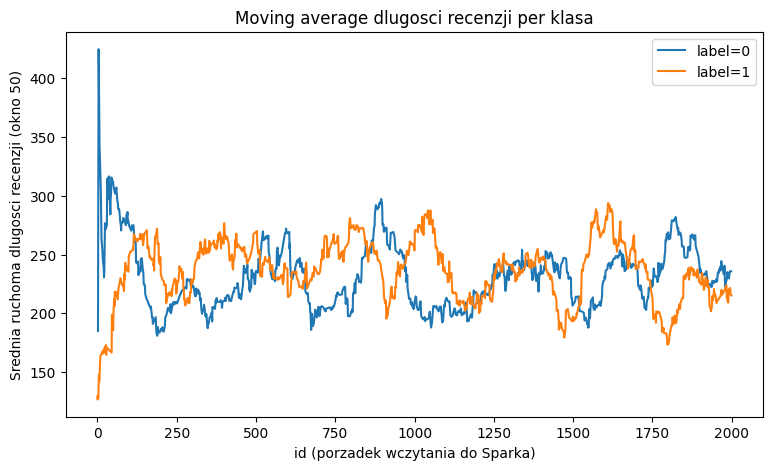


Wniosek: dane przeszly przez .shuffle(seed=42) w get_imdb_subset, wiec porzadek 'id' jest losowy wzgledem tresci -- srednia ruchoma powinna fluktuowac wokol sredniej klasowej bez systematycznego trendu. Gdyby trend byl widoczny, oznaczaloby to ze shuffle nie zadzialal (patrz ostrzezenie w README o danych sortowanych po labelu).


In [11]:
# Zadanie 5.1 -- te same okna, inny zestaw cech (na df_words z przykladu powyzej)
from pyspark.sql.window import Window

w_class = Window.partitionBy("label")
w_rank = Window.partitionBy("label").orderBy(F.col("word_count").desc())
w_moving = Window.partitionBy("label").orderBy("id").rowsBetween(-49, 0)

df_ranked = (
    df_words
    .withColumn("rank", F.row_number().over(w_rank))
    .withColumn("avg_in_class", F.round(F.avg("word_count").over(w_class), 1))
    .withColumn("diff_from_avg", F.col("word_count") - F.col("avg_in_class"))
    .withColumn("moving_avg_50", F.round(F.avg("word_count").over(w_moving), 1))
)

print("-- Top 3 najdluzsze recenzje per klasa --")
(
    df_ranked
    .filter(F.col("rank") <= 3)
    .select("id", "label", "word_count", "rank")
    .orderBy("label", "rank")
    .show()
)

print("-- Roznica od sredniej w klasie (przykladowe wiersze) --")
df_ranked.select("id", "label", "word_count", "avg_in_class", "diff_from_avg").show(5)

pdf_moving = df_ranked.select("id", "label", "moving_avg_50").orderBy("label", "id").toPandas()

fig, ax = plt.subplots(figsize=(9, 5))
for label, group in pdf_moving.groupby("label"):
    ax.plot(group["id"], group["moving_avg_50"], label=f"label={label}")
ax.set_xlabel("id (porzadek wczytania do Sparka)")
ax.set_ylabel("Srednia ruchoma dlugosci recenzji (okno 50)")
ax.set_title("Moving average dlugosci recenzji per klasa")
ax.legend()
plt.show()

print(
    "\nWniosek: dane przeszly przez .shuffle(seed=42) w get_imdb_subset, wiec porzadek "
    "'id' jest losowy wzgledem tresci -- srednia ruchoma powinna fluktuowac wokol "
    "sredniej klasowej bez systematycznego trendu. Gdyby trend byl widoczny, oznaczaloby "
    "to ze shuffle nie zadzialal (patrz ostrzezenie w README o danych sortowanych po labelu)."
)

---

# Lab 6 — Data Quality (jakość danych)

## Teoria w trzech zdaniach

**Data Quality** to nie audyt po wszystkim — to **kontrakt** który dane muszą spełnić zanim wejdą do pipeline'u. Sześć wymiarów: kompletność, unikalność, poprawność, zgodność, świeżość, integralność.

Współczesny stack: `pandera`/`great_expectations` dla **deklaratywnych testów**, `pandas-profiling` (teraz `ydata-profiling`) dla **raportów eksploracyjnych**, własne **walidatory** dla reguł biznesowych.

**Reguła:** jeśli nie potrafisz w jednym zdaniu opisać co znaczy "dobre dane" dla Twojego problemu, nie powinieneś jeszcze trenować modelu.

## Przykład rozwiązany: profilowanie imdb — wykrywanie anomalii

In [12]:
import pandas as pd

# Wczytaj wieksza probke
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()
df_pd["char_count"] = df_pd["text"].str.len()

# Profil podstawowy
print("=== KOMPLETNOSC ===")
nulls = df_pd.isnull().sum()
print(f"Nulle: {dict(nulls)}")

print("\n=== UNIKALNOSC ===")
dup_count = df_pd["text"].duplicated().sum()
print(f"Duplikaty tekstu: {dup_count}")

print("\n=== ROZKLAD LABELI ===")
print(df_pd["label"].value_counts(normalize=True).rename("frac"))
balance_ratio = df_pd["label"].value_counts().min() / df_pd["label"].value_counts().max()
print(f"Stosunek mniejszosci do wiekszosci: {balance_ratio:.3f} (1.0 = idealnie zbalansowane)")

print("\n=== ANOMALIE DLUGOSCI ===")
p99 = df_pd["word_count"].quantile(0.99)
p01 = df_pd["word_count"].quantile(0.01)
outliers = df_pd[(df_pd["word_count"] > p99) | (df_pd["word_count"] < p01)]
print(f"P1: {p01:.0f}, P99: {p99:.0f}, outlierow (poza P1-P99): {len(outliers)}")

print("\n=== ANOMALIE TRESCI ===")
has_html = df_pd["text"].str.contains(r"<[^>]+>", regex=True).sum()
very_short = (df_pd["word_count"] < 5).sum()
print(f"Tekst zawiera HTML tagi: {has_html} ({has_html/len(df_pd)*100:.1f}%)")
print(f"Bardzo krotkie recenzje (<5 slow): {very_short}")

print("\nINSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!")

  [timer] get_imdb_subset -> 0.00s
=== KOMPLETNOSC ===
Nulle: {'text': np.int64(0), 'label': np.int64(0), 'word_count': np.int64(0), 'char_count': np.int64(0)}

=== UNIKALNOSC ===
Duplikaty tekstu: 0

=== ROZKLAD LABELI ===
label
1    0.5
0    0.5
Name: frac, dtype: float64
Stosunek mniejszosci do wiekszosci: 1.000 (1.0 = idealnie zbalansowane)

=== ANOMALIE DLUGOSCI ===
P1: 42, P99: 889, outlierow (poza P1-P99): 39

=== ANOMALIE TRESCI ===
Tekst zawiera HTML tagi: 1189 (59.5%)
Bardzo krotkie recenzje (<5 slow): 0

INSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!


## Zadanie 6.1 — Kontrakt danych + raport JSON

**Cel:** zaimplementuj prosty *Data Quality Framework* w czystym Pythonie i wygeneruj raport o jakości datasetu.

**Wymagania:**

1. Klasa `DataContract` z metodą `add_rule(name, callable, severity)` (severity ∈ {`info`, `warning`, `error`}).
2. Klasa `DataValidator` która iteruje po regułach kontraktu i zwraca raport: `{rule_name: {passed: bool, severity, details}}`.
3. Zdefiniuj kontrakt dla imdb z **minimum 6 regułami**:
   - `no_nulls` — brak NULL w `text` i `label`
   - `labels_in_set` — wszystkie labele są w {0, 1}
   - `min_word_count` — każda recenzja ma min. 5 słów
   - `max_word_count` — żadna recenzja > 2000 słów (sanity)
   - `no_duplicates` — brak duplikatów `text`
   - `class_balance` — stosunek klas między 0.5 a 1.5
4. Reguły o severity `error` które zawiodły powinny rzucić wyjątek (fail fast). Reszta jest tylko ostrzeżeniem.
5. Wygeneruj raport w pliku `_workspace/data_quality_report.json` z timestampem.

**Bonus:** zaimplementuj `severity="warning"` regułę `no_html_tags` i pokaż że *raport* o niej mówi, ale walidacja nie zawodzi.

In [16]:
import json
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Callable

import pandas as pd


WORKDIR = Path(globals().get("WORKDIR", Path.cwd() / "_workspace"))
WORKDIR.mkdir(parents=True, exist_ok=True)

if "df_pd" not in globals():
    raise NameError(
        "Brakuje zmiennej df_pd. Uruchom wcześniejszą komórkę "
        "tworzącą pandas DataFrame z recenzjami IMDB."
    )

if "word_count" not in df_pd.columns:
    df_pd = df_pd.copy()
    df_pd["word_count"] = (
        df_pd["text"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )


@dataclass
class Rule:
    name: str
    check: Callable
    severity: str


class DataContract:
    def __init__(self, name: str):
        self.name = name
        self.rules: list[Rule] = []

    def add_rule(
        self,
        name: str,
        check: Callable,
        severity: str = "warning",
    ) -> None:
        allowed_severities = {"info", "warning", "error"}

        if severity not in allowed_severities:
            raise ValueError(
                f"Nieprawidłowe severity: {severity}. "
                f"Dozwolone wartości: {sorted(allowed_severities)}"
            )

        if not callable(check):
            raise TypeError("check musi być obiektem callable")

        if any(rule.name == name for rule in self.rules):
            raise ValueError(f"Reguła '{name}' już istnieje")

        self.rules.append(
            Rule(
                name=name,
                check=check,
                severity=severity,
            )
        )


class DataValidator:
    def __init__(self, contract: DataContract):
        self.contract = contract

    def validate(self, df: pd.DataFrame) -> dict:
        report = {}

        for rule in self.contract.rules:
            try:
                result = rule.check(df)

                if not isinstance(result, tuple) or len(result) != 2:
                    raise TypeError(
                        "Reguła musi zwracać krotkę (passed, details)"
                    )

                passed, details = result
                passed = bool(passed)
                details = str(details)

            except Exception as exc:
                passed = False
                details = (
                    f"Błąd wykonania reguły: "
                    f"{type(exc).__name__}: {exc}"
                )

            report[rule.name] = {
                "passed": passed,
                "severity": rule.severity,
                "details": details,
            }

            if rule.severity == "error" and not passed:
                raise ValueError(
                    f"Kontrakt złamany: {rule.name} — {details}"
                )

        return report


def check_no_nulls(df: pd.DataFrame) -> tuple[bool, str]:
    null_count = int(
        df[["text", "label"]]
        .isnull()
        .sum()
        .sum()
    )

    return (
        null_count == 0,
        f"nulli w text/label: {null_count}",
    )


def check_labels_in_set(df: pd.DataFrame) -> tuple[bool, str]:
    invalid_count = int(
        (~df["label"].isin([0, 1])).sum()
    )

    return (
        invalid_count == 0,
        f"etykiet poza {{0, 1}}: {invalid_count}",
    )


def check_min_word_count(df: pd.DataFrame) -> tuple[bool, str]:
    invalid_count = int(
        (df["word_count"] < 5).sum()
    )

    return (
        invalid_count == 0,
        f"recenzji poniżej 5 słów: {invalid_count}",
    )


def check_max_word_count(df: pd.DataFrame) -> tuple[bool, str]:
    invalid_count = int(
        (df["word_count"] > 2000).sum()
    )

    return (
        invalid_count == 0,
        f"recenzji powyżej 2000 słów: {invalid_count}",
    )


def check_no_duplicates(df: pd.DataFrame) -> tuple[bool, str]:
    duplicate_count = int(
        df["text"].duplicated().sum()
    )

    return (
        duplicate_count == 0,
        f"duplikatów text: {duplicate_count}",
    )


def check_class_balance(df: pd.DataFrame) -> tuple[bool, str]:
    counts = (
        df["label"]
        .value_counts()
        .reindex([0, 1], fill_value=0)
    )

    count_0 = int(counts.loc[0])
    count_1 = int(counts.loc[1])

    if count_0 == 0 or count_1 == 0:
        return (
            False,
            f"klasa 0: {count_0}, klasa 1: {count_1}",
        )

    ratio = count_0 / count_1

    return (
        0.5 <= ratio <= 1.5,
        (
            f"stosunek klasy 0 do klasy 1: {ratio:.3f} "
            f"({count_0}/{count_1})"
        ),
    )


def check_no_html_tags(df: pd.DataFrame) -> tuple[bool, str]:
    html_count = int(
        df["text"]
        .astype("string")
        .str.contains(
            r"<[^>]+>",
            regex=True,
            na=False,
        )
        .sum()
    )

    return (
        html_count == 0,
        f"recenzji zawierających HTML: {html_count}",
    )


contract = DataContract("imdb_reviews")

contract.add_rule(
    "no_nulls",
    check_no_nulls,
    severity="error",
)

contract.add_rule(
    "labels_in_set",
    check_labels_in_set,
    severity="error",
)

contract.add_rule(
    "min_word_count",
    check_min_word_count,
    severity="error",
)

contract.add_rule(
    "max_word_count",
    check_max_word_count,
    severity="warning",
)

contract.add_rule(
    "no_duplicates",
    check_no_duplicates,
    severity="warning",
)

contract.add_rule(
    "class_balance",
    check_class_balance,
    severity="warning",
)

contract.add_rule(
    "no_html_tags",
    check_no_html_tags,
    severity="warning",
)


validator = DataValidator(contract)
report = validator.validate(df_pd)

print("=== Raport walidacji ===")

for rule_name, result in report.items():
    status = "OK" if result["passed"] else "FAIL"

    print(
        f"[{status}] {rule_name} "
        f"({result['severity']}): "
        f"{result['details']}"
    )


report_payload = {
    "contract": contract.name,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "rows_checked": int(len(df_pd)),
    "rules": report,
}

report_path = WORKDIR / "data_quality_report.json"

report_path.write_text(
    json.dumps(
        report_payload,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(f"\nRaport zapisany: {report_path.resolve()}")


=== Raport walidacji ===
[OK] no_nulls (error): nulli w text/label: 0
[OK] labels_in_set (error): etykiet poza {0, 1}: 0
[OK] min_word_count (error): recenzji poniżej 5 słów: 0
[OK] max_word_count (warning): recenzji powyżej 2000 słów: 0
[OK] no_duplicates (warning): duplikatów text: 0
[OK] class_balance (warning): stosunek klasy 0 do klasy 1: 1.000 (1000/1000)
[FAIL] no_html_tags (warning): recenzji zawierających HTML: 1189

Raport zapisany: C:\Users\Radek\Desktop\python_zadania\AAP_LAB_TASKS\zestaw_zaliczeniowy\_workspace\data_quality_report.json


---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Dekorator:** kiedy `functools.wraps` jest konieczny, a kiedy można sobie odpuścić?
2. **Concurrency:** dlaczego threading nie przyspieszy obliczeń, a multiprocessing przyspieszy?
3. **Testowanie:** kiedy lepiej parametrize, a kiedy osobne testy?
4. **Bazy:** co znaczy *schema-on-read*? Daj praktyczny przykład gdy to plus, a kiedy minus.
5. **Spark:** co to znaczy że transformacja jest "lazy"? Daj przykład **kiedy to boli** w debugowaniu.
6. **Data Quality:** różnica między *audytem* a *kontraktem* danych. W produkcji potrzebujesz obu — dlaczego?

## Co dalej?

- **Pakowanie:** `pyproject.toml`, `poetry`, dystrybucja przez `pip`
- **CI/CD:** GitHub Actions, pre-commit hooks, automated testing
- **Observability:** logging structured (`structlog`), metryki (`prometheus_client`), tracing (`opentelemetry`)
- **Orchestration:** Apache Airflow / Prefect / Dagster do *prawdziwych* pipeline'ów
- **Workshops:** [Real Python](https://realpython.com), [Talk Python To Me](https://talkpython.fm) podcast

In [14]:
# Sprzatanie
try:
    spark.stop()
    print("Spark zatrzymany.")
except NameError:
    pass
print(f"Workspace: {WORKDIR.resolve()}")
print("Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.")

Spark zatrzymany.
Workspace: C:\Users\Radek\Desktop\python_zadania\AAP_LAB_TASKS\zestaw_zaliczeniowy\_workspace
Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.
